##Контрольная работа №3

ФИО  
ИД24-3

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc, classification_report
from numpy import argmax
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from sklearn.datasets import fetch_openml

1. (1 балл) Загрузите предложенный вам датасет с помощью функции `sklearn.datasets.fetch_openml`. Выведите текстовое описание загруженного датасета. Определите какая бизнес-задача ставится. Переведите бизнес-задачу в задачу машинного обучения.



In [5]:
data = fetch_openml(name='wholesale-customers', as_frame=True, parser='auto')

In [6]:
df = data.frame
df.head()

,V1,V2,V3,V4,V5,V6,V7,Channel,Region
0,3,12669,9656,7561,214,2674,1338,2,3
1,3,7057,9810,9568,1762,3293,1776,2,3
2,3,6353,8808,7684,2405,3516,7844,2,3
3,3,13265,1196,4221,6404,507,1788,1,3
4,3,22615,5410,7198,3915,1777,5185,2,3


Набор данных относится к клиентам оптового дистрибьютора. Он включает годовые расходы в денежных единицах (м.е.) на различные категории товаров.  
Бизнес-задача - определение типов клиентов, задача машинного обучения - классификация

2. (1 балл) Проведите предварительный анализ датасета.  Выведите основную статистическую информацию о данных. Проверьте дисбаланс целевого признака.

In [ ]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [8]:
y = df['Channel']
X = df.drop('Channel', axis=1)
X.shape, y.shape

((440, 8), (440,))

In [ ]:
print(df['Channel'].value_counts(normalize=True))

Channel
1    0.677273
2    0.322727
Name: proportion, dtype: float64


*дисбаланс класов либо распределение для регрессии*

умеренный дисбаланс классов - 0.7 на 0.3

3. (1 балл) Убедитесь, что данные пригодны для моделирования. В данных не должно быть пропущенных значений, все признаки должны быть численными. Если эти условия нарушаются, исправьте это.

*...Видно, что данные не содержат пропущенных значений*

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

4. (1 балл) Обучите любую линейную модель, которая решает поставленную задачу. Выведите с помощью метода `score()` результат метрики оценки модели. Опишите какая метрика подсчитывается в методе `score()`.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9090909090909091


В метрике score подсчитывается точность - accuracy (доля правильных ответов модели относительно общего количества прогнозов).  
Отличие score() от accuracy() заключается в том, что accursacy принимает (y_predicted,y),  а метод score принимает (X,y) и сам рассчитывает предсказанные значения y.

5. (1 балл) К поставленной задачи машинного обучения подберите еще 3 метрики. С помощью их оцените обученную линейную модель.


In [14]:
precision = precision_score(y_test, y_pred, pos_label='2')
recall = recall_score(y_test, y_pred, pos_label='2')
f1 = f1_score(y_test, y_pred, pos_label='2')
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Precision: 0.8611111111111112
Recall: 0.8157894736842105
F1 score: 0.8378378378378378


6. (1 балл) Для задач классификации: Постройте для этой модели кривые ROC. Вычислите для этой модели метрики площади под кривыми ROC-AUC. Найдите оптимальное значения порога модели.




In [20]:
y_train_binary = y_train.replace({'1': 0, '2': 1})
y_test_binary = y_test.replace({'1': 0, '2': 1})

/tmp/ipykernel_11664/972597695.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train_binary = y_train.replace({'1': 0, '2': 1})
/tmp/ipykernel_11664/972597695.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_train_binary = y_train.replace({'1': 0, '2': 1})
/tmp/ipykernel_11664/972597695.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_

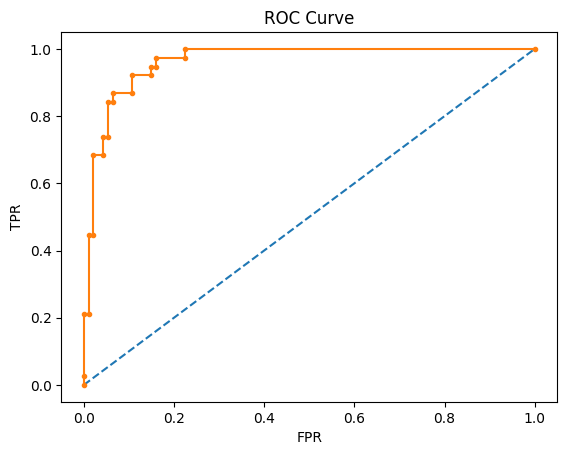

ROC-AUC Score: 0.9633258678611423


In [21]:
y_pred_proba = model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test_binary, y_pred_proba[:, 1])
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.title('ROC Curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

roc_auc = roc_auc_score(y_test_binary, y_pred_proba[:, 1])
print("ROC-AUC Score:", roc_auc)

6. (1 балл) Для задач регрессии: Постройте совместное распределение теоретических и эмпирических значений целевой переменной. Сделайте вывод о наличии либо отсутствии систематической компоненты в отклонениях, их общей величине.

7. (1 балл) Для задач классификации: Постройте для этой модели кривые PR. Вычислите для этой модели метрики площади под кривыми PR-AUC. Найдите оптимальное значения порога модели.


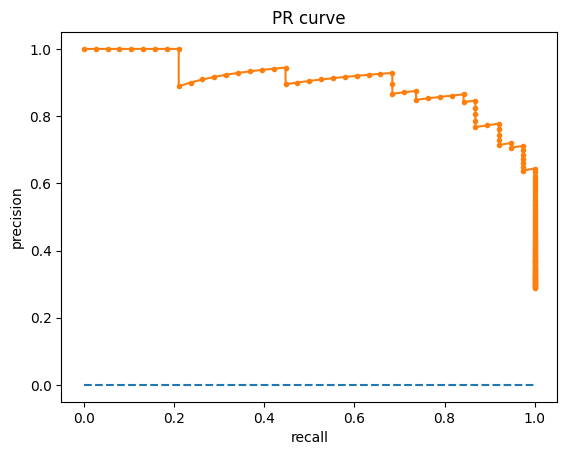

AUC: 0.8988498090583595


In [22]:
precision, recall, pr_thresholds = precision_recall_curve(y_test_binary, y_pred_proba[:,1])
no_skill= len(y[y==1])/len(y)
plt.plot([0,1], [no_skill,no_skill], linestyle ='--')
plt.plot(recall, precision, marker='.')
plt.xlabel('recall')
plt.ylabel('precision')
plt.title('PR curve')
plt.show()
print('AUC:', auc(recall, precision))

In [23]:
f1_list = (2*precision*recall)/(precision+recall)
ix = argmax(f1_list)
pr_thresholds[ix]
print('Порог=%f, F1=%.3f' % (pr_thresholds[ix], f1_list[ix]))

Порог=0.447482, F1=0.857


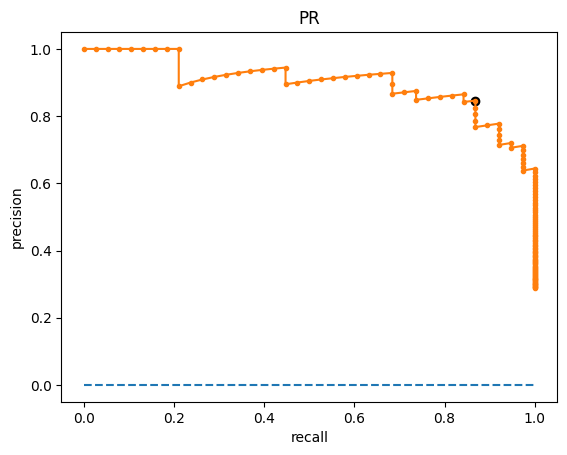

In [24]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.scatter(recall[ix], precision[ix], marker='o', color='black')
plt.title('PR')
plt.ylabel('precision')
plt.xlabel('recall')
plt.show()

7. (1 балл) Для задач регрессии: Постройте ту же модель, но с предварительной нормализацией значений признаков. Сделайте вывод о влиянии нормализации на качество работы модели.


8. (1 балл) Обоснуйте выбор типа разбиения данных при кросс-валидации для вашей задачи машинного обучения. Обучите любую другую модель используя кросс-валидацию данных.


Для данной задачи лучше всего подходит StratifiedKFold. Она гарантирует, что в каждом фолде будет сохраняться то же соотношение классов Channel, что и во всей выборке.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_cv = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(model_cv, X_scaled, y, cv=cv, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", np.mean(cv_scores))

Cross-validation scores: [0.89772727 0.93181818 0.90909091 0.93181818 0.94318182]
Mean accuracy: 0.9227272727272726


9. (2 балл) Проведите диагностику любой модели. Постройте кривые обучения. Сделайте вывод о переобученности или недообученности модели.


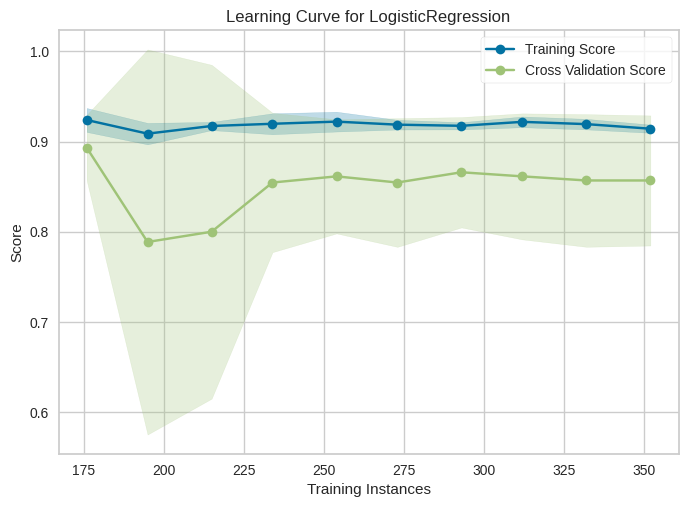

In [27]:
from yellowbrick.model_selection import LearningCurve

visualizer = LearningCurve(
    LogisticRegression(max_iter=1000), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X_scaled, y).show()

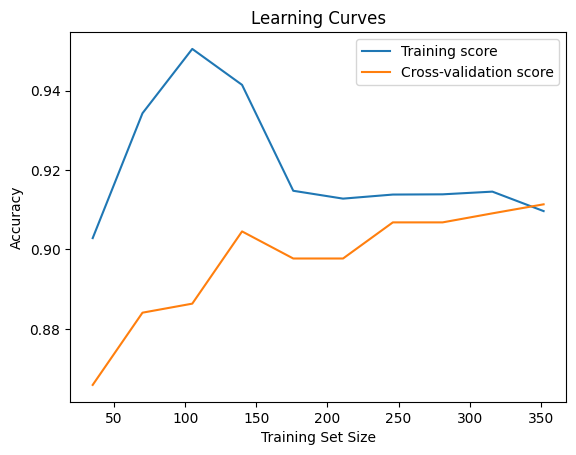

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(), X_scaled, y, cv=cv, train_sizes=np.linspace(0.1, 1.0, 10))

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.title('Learning Curves')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

В начале мы видим  небольшое переобучение, затем, с ростом данных, разрыв между кривыми сокращается. Модель подходит для данного набора данных

10. (2 балл) Исследуйте как любой из гиперпараметров модели влияет на эффективность модели.

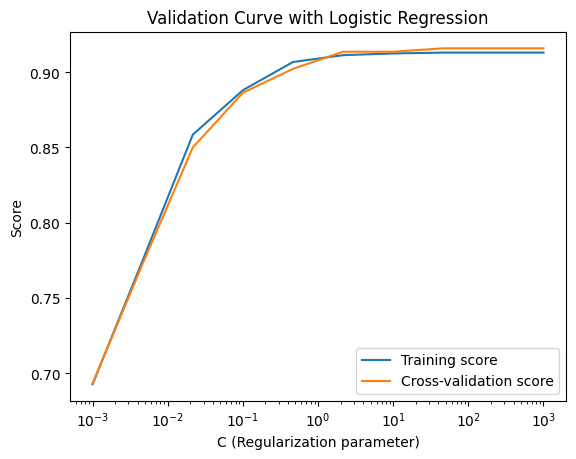

In [ ]:
from sklearn.model_selection import validation_curve

param_range = np.logspace(-3, 3, 10)
train_scores, test_scores = validation_curve(
    LogisticRegression(max_iter=1000), X_scaled, y,
    param_name="C", param_range=param_range, cv=cv, scoring="accuracy"
)

plt.semilogx(param_range, np.mean(train_scores, axis=1), label="Training score")
plt.semilogx(param_range, np.mean(test_scores, axis=1), label="Cross-validation score")
plt.title("Validation Curve with Logistic Regression")
plt.xlabel("C (Regularization parameter)")
plt.ylabel("Score")
plt.legend()
plt.show()

Варианты
students_scores
wholesale-customers
pc1_req
vertebra-column
prnn_crabs
cloud
fertility
ricci_vs_destefano
machine_cpu
lupus
energy-efficiency
LED-display-domain-7digit
diggle_table_a2
ecoli
breast-tissue
prnn_fglass
confidence
glass
user-knowledge
olindda_outliers
